# Converting a mesh between formats with meshio++

meshio++ converts one in-memory `Mesh` to any of its 35+ formats. Here we
take the bracket geometry from `example.msh` and write it to several
formats, compare the resulting file sizes, and verify the round trip.

In [1]:
import os
import tempfile

import numpy as np
import matplotlib.pyplot as plt

import meshioplusplus as mp

EXAMPLE = os.path.join(os.path.dirname(os.getcwd()), 'example.msh')
if not os.path.exists(EXAMPLE):
    EXAMPLE = os.path.join('..', 'example.msh')  # when run from example/python/ with a different cwd

src = mp.read(EXAMPLE)
# Keep the portable geometry (surface triangles + solid tetrahedra); the
# original file also carries per-entity vertex/line groups and gmsh tags.
tri = np.concatenate([cb.data for cb in src.cells if cb.type == 'triangle'])
tet = np.concatenate([cb.data for cb in src.cells if cb.type == 'tetra'])
mesh = mp.Mesh(src.points, [('triangle', tri), ('tetra', tet)])
print(f'{len(mesh.points):,} points, {len(tri):,} triangles, {len(tet):,} tetrahedra')


52,282 points, 58,394 triangles, 235,014 tetrahedra


## Convert to several formats

In [2]:
tmpdir = tempfile.mkdtemp()

# (label, filename, write kwargs)
targets = [
    ('vtu (ascii)',       'mesh_ascii.vtu', dict(binary=False)),
    ('vtu (binary+zlib)', 'mesh.vtu',       dict(binary=True)),
    ('vtk (binary)',      'mesh.vtk',       dict(binary=True)),
    ('xdmf',              'mesh.xdmf',      {}),
    ('gmsh (binary)',     'mesh.msh',       dict(binary=True, file_format='gmsh')),
    ('ply (binary)',      'mesh.ply',       dict(binary=True)),
]

def total_size(path):
    # XDMF writes a companion .h5; count the sidecar too.
    size = os.path.getsize(path)
    h5 = os.path.splitext(path)[0] + '.h5'
    if path.endswith('.xdmf') and os.path.exists(h5):
        size += os.path.getsize(h5)
    return size

results = []
for label, fn, kw in targets:
    path = os.path.join(tmpdir, fn)
    mesh.write(path, **kw)
    mb = total_size(path) / 1e6
    results.append((label, path, kw, mb))
    print(f'{label:20s} {mb:7.2f} MB')

vtu (ascii)            12.31 MB
vtu (binary+zlib)       4.77 MB
vtk (binary)           13.70 MB


xdmf                    3.45 MB
gmsh (binary)          12.94 MB


ply (binary)            1.46 MB


meshio warning [ply.cpp:405] PLY: writing the extracted skin of the volume cells; 1 pre-existing non-volume cell block(s) dropped (pass skin=false for the legacy behavior).


## Physics-ML export targets

Four of meshio++'s formats exist to feed a training pipeline rather than
another mesh tool: `pmsh` and `zarr` write the two layouts NVIDIA
PhysicsNeMo's own `MeshDataset` reads, `cae` writes the per-case `.npz`
sample its DoMINO and Transolver datapipes read, and `usd` writes a
time-sampled OpenUSD stage. The first three are lossy by design — each
reduces a mesh to what its consumer's data model holds — so they warn about
what they dropped rather than doing it quietly.

`pmsh` and `zarr` hold exactly one simplex kind, so the bracket's triangles
and tetrahedra cannot both survive: the tetrahedra win and the reduction is
reported.

In [3]:
# One simplex kind per file: the surface triangles are dropped with a warning.
pmsh_path = os.path.join(tmpdir, 'bracket.pmsh')
mp.write(pmsh_path, mesh)
back = mp.read(pmsh_path)
print(f'pmsh  -> {len(back.points):,} points, '
      f'{[(b.type, len(b.data)) for b in back.cells]}, '
      f'memory-mapped: {isinstance(back.points.base, np.memmap)}')

if mp.has_zarr():
    zarr_path = os.path.join(tmpdir, 'bracket.zarr')
    mp.write(zarr_path, mesh)
    print(f'zarr  -> {len(mp.read(zarr_path).points):,} points')

# The CAE sample: the solid's skin, triangulated, plus its nodes and fields.
field = mesh.points[:, 2]
sample = mp.Mesh(mesh.points, [('tetra', tet)], point_data={'height': field})
npz_path = os.path.join(tmpdir, 'case_0.npz')
mp.cae.write(npz_path, sample, global_params={'stream_velocity': 30.0}, time=0.0, step=0)

with np.load(npz_path) as data:
    for key in ('stl_coordinates', 'stl_faces', 'stl_areas', 'surface_normals',
                'surface_fields', 'volume_mesh_centers', 'volume_fields'):
        print(f'{key:22s} {str(data[key].dtype):8s} {data[key].shape}')
    print(f'total surface area {float(data["stl_areas"].sum()):.4f}')

Warning: pmsh: physicsnemo.mesh.Mesh is single-manifold-dim; dropped triangle x 58394 -- export each dimension as 
its own Mesh

pmsh  -> 52,282 points, [('tetra', 235014)], memory-mapped: True


Warning: zarr: physicsnemo.mesh.Mesh is single-manifold-dim; dropped triangle x 58394 -- export each dimension as 
its own Mesh

zarr  -> 52,282 points


stl_coordinates        float32  (29151, 3)
stl_faces              int32    (175182,)
stl_areas              float32  (58394,)
surface_normals        float32  (58394, 3)
surface_fields         float32  (58394, 1)
volume_mesh_centers    float32  (52282, 3)
volume_fields          float32  (52282, 1)
total surface area 20.8405


### The exported surface, rendered

`cae.read` gives the surface half back as a triangle mesh whose `cell_data`
carries the normals, areas and the named field blocks split back apart — so
the thing the training pipeline will actually see can be looked at directly.
Coloured here by `height`, the nodal field the exporter averaged onto each
triangle from its three vertices.

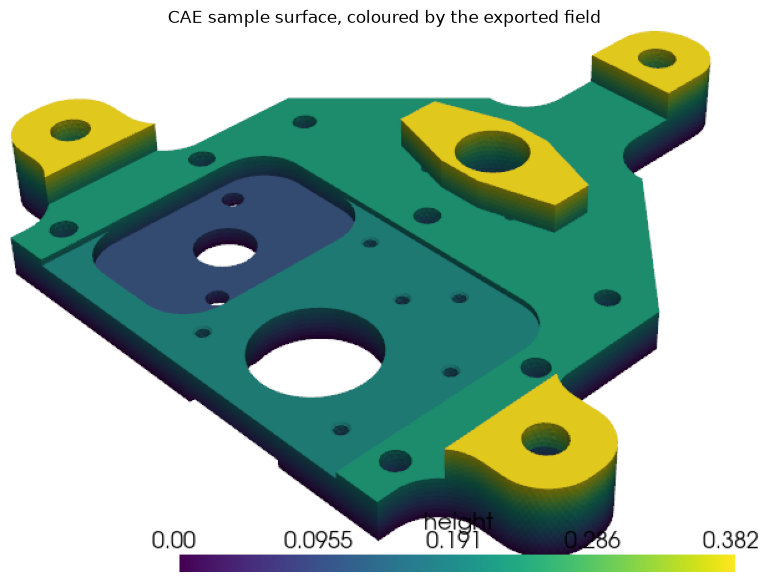

In [4]:
surface = mp.cae.read(npz_path)          # the surface half
height = surface.cell_data['height'][0]

def crop_white(img, tol=250):
    # The renderer pads its viewport; trim the uniform border so the part
    # fills the figure instead of floating in it.
    mask = (img[:, :, :3] < tol).any(axis=2)
    rows, cols = np.where(mask.any(axis=1))[0], np.where(mask.any(axis=0))[0]
    if not len(rows) or not len(cols):
        return img
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

try:
    import pyvista as pv

    pv.OFF_SCREEN = True
    vtp = os.path.join(tmpdir, 'surface.vtp')
    mp.write(vtp, mp.Mesh(surface.points, surface.cells,
                          cell_data={'height': [height]}))
    grid = pv.read(vtp)
    plotter = pv.Plotter(off_screen=True, window_size=(900, 620))
    plotter.add_mesh(grid, scalars='height', cmap='viridis', show_edges=False,
                     scalar_bar_args=dict(title='height', vertical=False,
                                          position_x=0.25, position_y=0.02,
                                          width=0.5, height=0.06))
    plotter.view_isometric()
    plotter.camera.zoom(1.4)
    img = crop_white(plotter.screenshot(return_img=True))
    plotter.close()

    fig, ax = plt.subplots(figsize=(8.2, 8.2 * img.shape[0] / img.shape[1]))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title('CAE sample surface, coloured by the exported field')
    plt.tight_layout()
    plt.show()
except Exception as exc:  # head-less GL, or no PyVista
    print(f'PyVista render unavailable ({exc}); showing the distribution instead')
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hist(height, bins=60, color='#3987e5')
    ax.set_xlabel('height')
    ax.set_ylabel('triangles')
    ax.set_title('CAE sample surface: exported field distribution')
    plt.tight_layout()
    plt.show()

## Compare file sizes

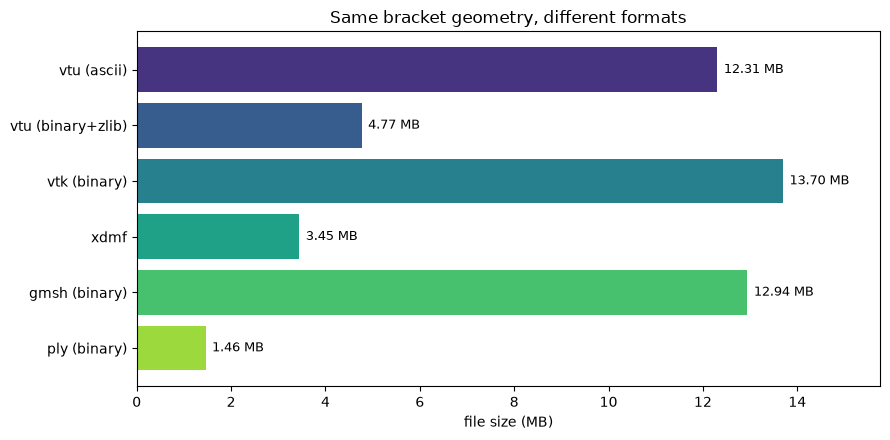

In [5]:
labels = [r[0] for r in results]
sizes = [r[3] for r in results]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(labels)))

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(labels, sizes, color=colors)
ax.invert_yaxis()
ax.set_xlabel('file size (MB)')
ax.set_title('Same bracket geometry, different formats')
for bar, mb in zip(bars, sizes):
    ax.text(bar.get_width() + max(sizes) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{mb:.2f} MB', va='center', fontsize=9)
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

## Round-trip verification

Read every file back and check the counts survive.

In [6]:
n_pts = len(mesh.points)
n_cells = len(tri) + len(tet)
for label, path, kw, _ in results:
    back = mp.read(path, file_format=kw.get('file_format'))
    bpts = len(back.points)
    bcells = sum(len(cb.data) for cb in back.cells)
    ok = (bpts == n_pts) and (bcells == n_cells)
    status = 'OK ' if ok else 'DIFF'
    print(f'{status} {label:20s} points={bpts:,} cells={bcells:,}')

OK  vtu (ascii)          points=52,282 cells=293,408
OK  vtu (binary+zlib)    points=52,282 cells=293,408
OK  vtk (binary)         points=52,282 cells=293,408
OK  xdmf                 points=52,282 cells=293,408
OK  gmsh (binary)        points=52,282 cells=293,408
DIFF ply (binary)         points=29,151 cells=58,394


Every format round-trips the geometry. For the timing difference between
meshio++ and the original pure-Python meshio, see the
[benchmarks](../benchmark/01_benchmark.ipynb).